# Two coupled modes: from a single oscillator to a phononic comb

This notebook picks up where `sample.ipynb` stops. That notebook built **one** driven, damped oscillator. Here we add the second mode and the coupling from the paper (Eqs. S1.1–S1.2):

$$\ddot{x}_1 + 2\gamma_1\dot{x}_1 + \omega_1^2 x_1 + \alpha_{22}x_2^2 = F\cos(\omega_D t)$$
$$\ddot{x}_2 + 2\gamma_2\dot{x}_2 + \omega_2^2 x_2 + \alpha_{12}x_1x_2 = 0$$

- **Mode 1** is driven, with $\omega_D \approx \omega_1$. It's the same equation as cell 3 of `sample.ipynb`, plus the coupling term.
- **Mode 2** has no drive. It only gets energy through $\alpha_{12}x_1x_2$, and it sits near $\omega_2 \approx \omega_1/2$ (2:1 resonance).

We keep mode 1 at **10 Hz**, the same as in `sample.ipynb`. The other parameters are chosen to reproduce the paper's normalized values from Fig. 3. That way the paper's threshold formulas tell us exactly which drive levels give no coupling, steady parametric resonance, or a comb.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import butter, filtfilt, find_peaks

BLUE, ORANGE = "#2a78d6", "#eb6834"   # mode 1, mode 2

## 1. Parameters (the knobs to tweak)

The paper works in **normalized** units, so most knobs are set that way and converted to physical values below:

| Knob | Paper symbol | Meaning |
|---|---|---|
| `f1` | $\omega_1/2\pi$ | Mode 1 frequency (Hz) |
| `Q1` | $Q_1=\omega_1/2\gamma_1$ | Mode 1 quality factor |
| `gamma21` | $\gamma_{21}=\gamma_2/\gamma_1$ | Ratio of damping rates |
| `Delta1` | $\Delta_1=(\omega_D-\omega_1)/\gamma_1$ | Drive detuning from mode 1, in linewidths |
| `kappa` | $\kappa$ | Mistuning of the 2:1 ratio. Sets $\Delta_2=\Delta_1/2+\kappa$ |
| `alpha` | $\alpha_{12}=\alpha_{22}$ | Coupling strength (only scales the amplitudes) |

The **drive strength** is passed separately as the normalized $f = \dfrac{\alpha_{12}}{8\gamma_1^2\omega_D^2}F$.

Paper Fig. 3 uses $\Delta_1=5$, $\kappa=-9$, $\gamma_{21}=1$, $f=20$.

In [2]:
f1      = 10.0     # Hz, same as sample.ipynb
Q1      = 300.0
gamma21 = 1.0
Delta1  = 5.0
kappa   = -9.0
alpha   = 100.0

def derived(f1=f1, Q1=Q1, gamma21=gamma21, Delta1=Delta1, kappa=kappa, alpha=alpha):
    """Convert the normalized knobs into physical parameters."""
    w1 = 2*np.pi*f1
    g1 = w1/(2*Q1)
    g2 = gamma21*g1
    wD = w1 + Delta1*g1
    Delta2 = Delta1/2 + kappa
    w2 = (wD - 2*g1*Delta2)/2          # from Delta2 = (wD - 2 w2) / (2 g1)
    return dict(w1=w1, w2=w2, g1=g1, g2=g2, wD=wD, Delta1=Delta1, Delta2=Delta2,
                gamma21=gamma21, alpha=alpha, Q2=w2/(2*g2))

p = derived()
print(f"mode 1: f1 = {p['w1']/2/np.pi:.4f} Hz,  Q1 = {Q1:.0f},  gamma1 = {p['g1']:.4f} 1/s")
print(f"mode 2: f2 = {p['w2']/2/np.pi:.4f} Hz,  Q2 = {p['Q2']:.0f},  gamma2 = {p['g2']:.4f} 1/s")
print(f"drive : fD = {p['wD']/2/np.pi:.4f} Hz")
print(f"Delta1 = {p['Delta1']},  Delta2 = {p['Delta2']}")

mode 1: f1 = 10.0000 Hz,  Q1 = 300,  gamma1 = 0.1047 1/s
mode 2: f2 = 5.1500 Hz,  Q2 = 154,  gamma2 = 0.1047 1/s
drive : fD = 10.0833 Hz
Delta1 = 5.0,  Delta2 = -6.5


## 2. What the paper predicts

Two thresholds in the normalized drive $f$:

1. **Parametric resonance** (black line, Fig. 2). Mode 2 turns on when Eq. (7) has a positive root for $|\psi_{2P}|^2$:
$$|\psi_{2P}|^4 + (\gamma_{21}-\Delta_1\Delta_2)|\psi_{2P}|^2 + \tfrac14(1+\Delta_1^2)(\gamma_{21}^2+\Delta_2^2) - f^2 = 0$$
2. **Comb** (red line, Fig. 2). The steady state goes unstable and the amplitudes start pulsing once $|\psi_{2P}|^2$ exceeds Eq. (10):
$$|\psi_{2P}|^2 \ge -\frac{\gamma_{21}(1+\Delta_1^2)\,[1+\Delta_1^2+4\gamma_{21}(1+\gamma_{21})]}{4(1+\gamma_{21})^2\,(1+\Delta_1^2+2\gamma_{21}+2\Delta_1\Delta_2)}$$

A comb is only possible at all if $2\Delta_1\Delta_2 \le -(1+\Delta_1^2+2\gamma_{21})$.

In [3]:
def thresholds(p):
    D1, D2, g21 = p['Delta1'], p['Delta2'], p['gamma21']
    b  = g21 - D1*D2
    c0 = 0.25*(1 + D1**2)*(g21**2 + D2**2)
    # Eq. (7): x^2 + b x + c0 - f^2 = 0, need a root x = |psi2P|^2 > 0
    f_par = np.sqrt(c0) if b >= 0 else np.sqrt(max(c0 - b**2/4, 0))
    comb_possible = 2*D1*D2 <= -(1 + D1**2 + 2*g21)
    if not comb_possible:
        return f_par, np.inf
    x_min = -g21*(1+D1**2)*(1+D1**2+4*g21*(1+g21)) / (4*(1+g21)**2*(1+D1**2+2*g21+2*D1*D2))   # Eq. (10)
    f_comb = np.sqrt(x_min**2 + b*x_min + c0)    # drive that gives |psi2P|^2 = x_min
    return f_par, max(f_comb, f_par)

f_par, f_comb = thresholds(p)
print(f"parametric resonance starts at f = {f_par:.2f}")
print(f"comb starts at                f = {f_comb:.2f}")

parametric resonance starts at f = 16.77
comb starts at                f = 18.26


## 3. The simulation

Same approach as `sample.ipynb`, but the state is now $[x_1, v_1, x_2, v_2]$.

Two details matter:
- **Seed mode 2 with a tiny nonzero value** (`x2_0 = 1e-4`). If $x_2$ starts at exactly 0, then $\alpha_{12}x_1x_2 = 0$ forever and mode 2 can never turn on, no matter how hard you drive. In a real device, thermal noise provides this seed.
- **Tight tolerances.** `rtol=1e-8` keeps the solver from creating fake amplitude drift over thousands of cycles. The comb sidebands we're looking for are small.

The amplitudes are converted back to the paper's $\psi_1 = \frac{\alpha_{12}}{4\gamma_1\omega_D}|u_1|$ so they can be checked against its formulas.

In [4]:
def envelope(x, t, w_carrier, cutoff_hz=1.0):
    """Slowly varying amplitude |u|: shift the carrier to 0 Hz, then low-pass.
    This is exactly the paper's x = (u e^{iwt} + c.c.)/2 decomposition."""
    z = x*np.exp(-1j*w_carrier*t)
    b, a = butter(4, cutoff_hz, fs=1/(t[1]-t[0]))
    return 2*np.abs(filtfilt(b, a, z))

def simulate(f_norm, p=p, T=300.0, dt=0.005, x2_0=1e-4):
    w1, w2, g1, g2, wD, a = p['w1'], p['w2'], p['g1'], p['g2'], p['wD'], p['alpha']
    F = f_norm*8*g1**2*wD**2/a        # normalized f  ->  physical F

    def rhs(t, y):
        x1, v1, x2, v2 = y
        return [v1, F*np.cos(wD*t) - 2*g1*v1 - w1**2*x1 - a*x2**2,
                v2,               - 2*g2*v2 - w2**2*x2 - a*x1*x2]

    t = np.arange(0, T, dt)
    s = solve_ivp(rhs, (0, T), [0, 0, x2_0, 0], t_eval=t,
                  method="DOP853", rtol=1e-8, atol=1e-10)
    return s.t, s.y[0], s.y[2]

def plot_case(f_norm, title, p=p, T=300.0, t_settle=100.0):
    t, x1, x2 = simulate(f_norm, p, T)
    env1 = envelope(x1, t, p['wD'])
    env2 = envelope(x2, t, p['wD']/2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(t, x1, color=BLUE, lw=0.3, alpha=0.35)
    ax1.plot(t, x2, color=ORANGE, lw=0.3, alpha=0.35)
    ax1.plot(t, env1, color=BLUE, lw=2, label="mode 1 envelope")
    ax1.plot(t, env2, color=ORANGE, lw=2, ls="--", label="mode 2 envelope")
    ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Displacement")
    ax1.set_title(f"{title}  (f = {f_norm})"); ax1.legend(loc="upper right")
    ax1.grid(alpha=0.2)

    m = t > t_settle                         # skip the ring-up
    win = np.hanning(m.sum())
    freqs = np.fft.rfftfreq(m.sum(), t[1]-t[0])
    for x, c, ls, lab in [(x1, BLUE, "-", "x1"), (x2, ORANGE, "--", "x2")]:
        X = np.abs(np.fft.rfft(x[m]*win))
        ax2.plot(freqs, 20*np.log10(X/X.max() + 1e-16), color=c, ls=ls, lw=1.2, label=lab)
    ax2.set_xlim(4, 11.5); ax2.set_ylim(-140, 5)
    ax2.set_xlabel("Frequency (Hz)"); ax2.set_ylabel("FFT (dB, each normalized)")
    ax2.set_title("Spectrum after ring-up"); ax2.legend(loc="upper left"); ax2.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

    late = (t > T - 100) & (t < T - 5)
    psi1 = p['alpha']*env1[late].mean()/(4*p['g1']*p['wD'])
    ripple1 = (env1[late].max() - env1[late].min())/env1[late].mean()
    print(f"mode 2 amplitude (late): {env2[late].mean():.3g}")
    print(f"envelope ripple of mode 1: {100*ripple1:.1f}%   (≈0 = steady, large = pulsing/comb)")
    print(f"psi1 (paper units): {psi1:.2f}")
    return t, x1, x2

## 4. Case A: below threshold ($f = 10 < f_{par}$)

Mode 1 behaves exactly like the driven oscillator in `sample.ipynb`. Mode 2's seed just decays away.

**Check:** the linear solution is $\psi_{1L} = f/(i+\Delta_1)$, so $|\psi_1| = 10/\sqrt{26} = 1.96$.

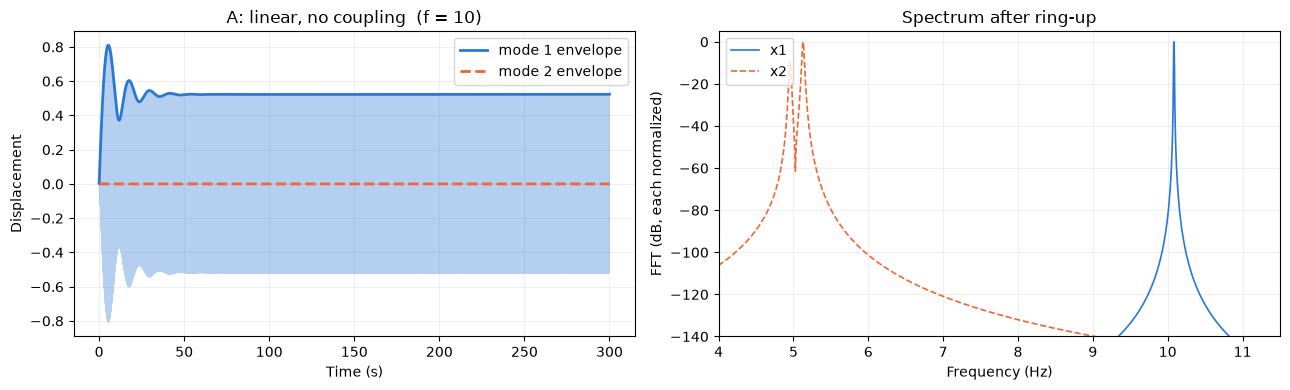

mode 2 amplitude (late): 9.28e-15
envelope ripple of mode 1: 0.0%   (≈0 = steady, large = pulsing/comb)
psi1 (paper units): 1.97


In [5]:
_ = plot_case(10, "A: linear, no coupling")

## 5. Case B: parametric resonance ($f_{par} < f = 17.5 < f_{comb}$)

Mode 2 switches on after a delay, because it has to grow from the tiny seed. Both modes then settle to **constant** amplitudes, so each spectrum is still a single clean peak. Mode 1 is now **saturated**: pushing harder only grows mode 2.

**Check:** the paper says $|\psi_{1P}| = \tfrac12\sqrt{\gamma_{21}^2+\Delta_2^2}$, independent of $f$.

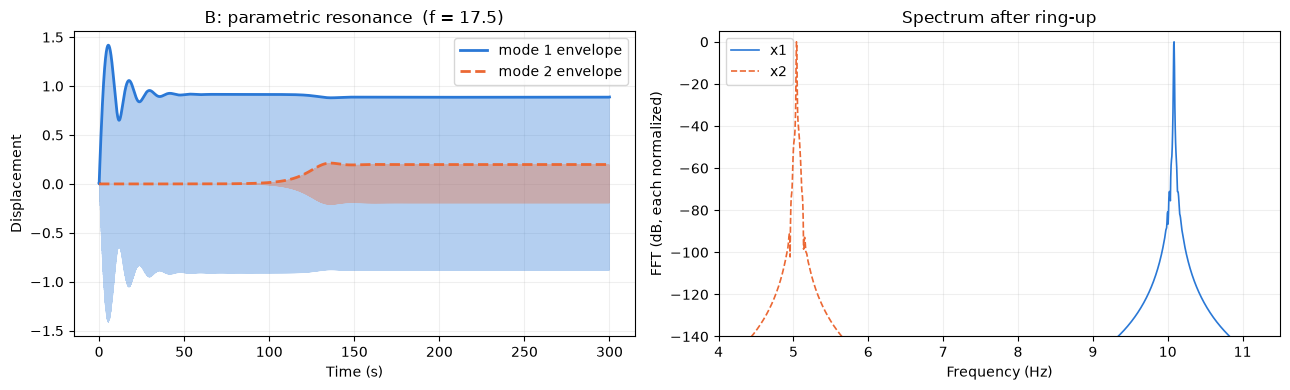

mode 2 amplitude (late): 0.198
envelope ripple of mode 1: 0.0%   (≈0 = steady, large = pulsing/comb)
psi1 (paper units): 3.34
paper prediction |psi1P| = 3.29


In [6]:
_ = plot_case(17.5, "B: parametric resonance")
print(f"paper prediction |psi1P| = {0.5*np.sqrt(p['gamma21']**2 + p['Delta2']**2):.2f}")

## 6. Case C: phononic comb ($f = 20 > f_{comb}$)

The steady state is now unstable (the Hopf bifurcation, Eq. 10). Energy sloshes back and forth between the modes, the envelopes pulse periodically, and each peak in the spectrum splits into a ladder of equally spaced lines. **That ladder is the frequency comb.** These are the paper's exact Fig. 3 parameters.

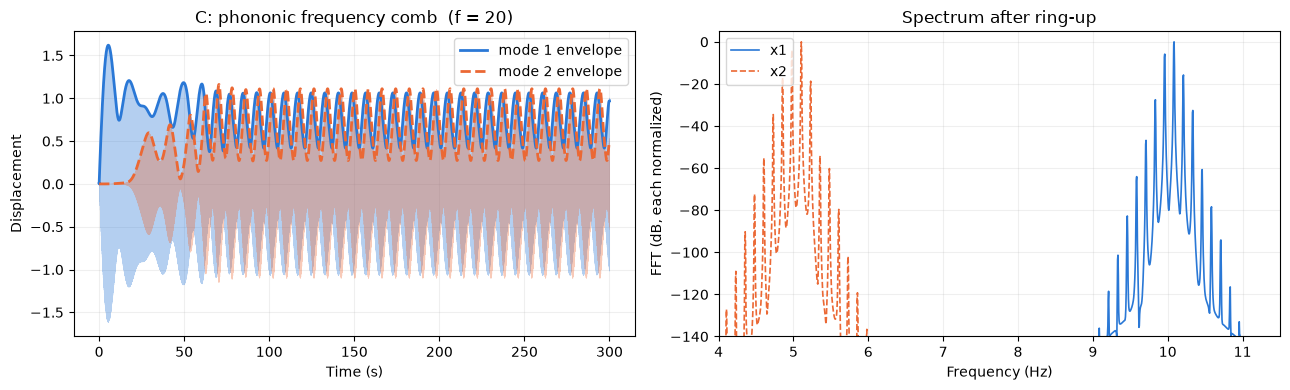

mode 2 amplitude (late): 0.676
envelope ripple of mode 1: 84.6%   (≈0 = steady, large = pulsing/comb)
psi1 (paper units): 2.87
pulse period = 8.00 s  ->  comb line spacing = 0.125 Hz


In [7]:
t, x1, x2 = plot_case(20, "C: phononic frequency comb")

# comb spacing = 1 / pulse period
env1 = envelope(x1, t, p['wD']); late = (t > 150) & (t < 295)
pk, _ = find_peaks(env1[late], prominence=0.1*env1[late].max())
period = np.mean(np.diff(t[late][pk]))
print(f"pulse period = {period:.2f} s  ->  comb line spacing = {1/period:.3f} Hz")

## 7. Sweep the drive and compare with the paper

This runs the full equations across a range of $f$ and measures how much the envelope pulses. The ripple should be about 0 below $f_{comb}$ and jump up past it. Mode 2 should switch on at $f_{par}$. (This cell takes about a minute.)

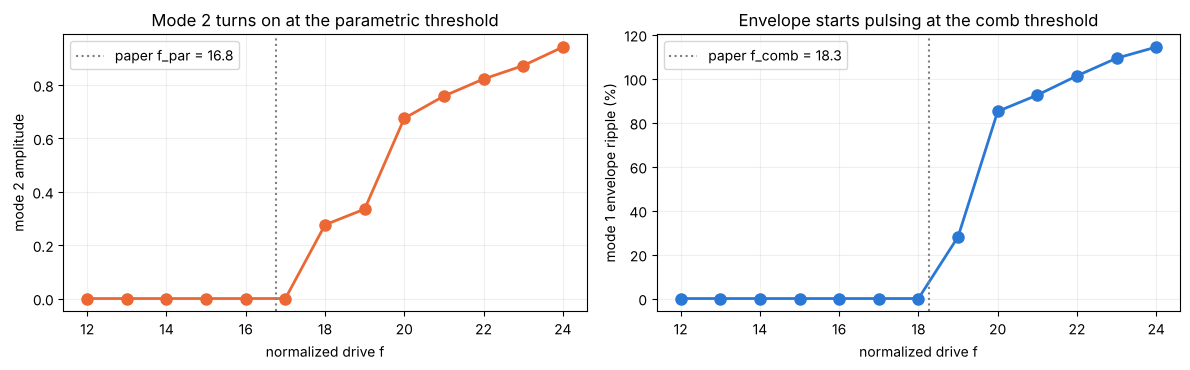

In [8]:
f_values = np.arange(12, 24.1, 1.0)
amp2, ripple = [], []
for fv in f_values:
    t, x1, x2 = simulate(fv, T=250)
    late = (t > 150) & (t < 245)
    e1, e2 = envelope(x1, t, p['wD'])[late], envelope(x2, t, p['wD']/2)[late]
    amp2.append(e2.mean())
    ripple.append(100*(e1.max() - e1.min())/e1.mean())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(f_values, amp2, "o-", color=ORANGE, lw=2, ms=8)
a1.axvline(f_par, color="gray", ls=":", label=f"paper f_par = {f_par:.1f}")
a1.set_xlabel("normalized drive f"); a1.set_ylabel("mode 2 amplitude"); a1.legend(); a1.grid(alpha=0.2)
a1.set_title("Mode 2 turns on at the parametric threshold")
a2.plot(f_values, ripple, "o-", color=BLUE, lw=2, ms=8)
a2.axvline(f_comb, color="gray", ls=":", label=f"paper f_comb = {f_comb:.1f}")
a2.set_xlabel("normalized drive f"); a2.set_ylabel("mode 1 envelope ripple (%)"); a2.legend(); a2.grid(alpha=0.2)
a2.set_title("Envelope starts pulsing at the comb threshold")
plt.tight_layout(); plt.show()

## 8. Things to try

Change one knob in **Section 1**, rerun everything, and compare with the paper:

1. **Flip the detuning:** `Delta1 = -5`, `kappa = 9`. This puts the comb on the other side of resonance (Fig. 2a vs 2b).
2. **Remove the mistuning:** `kappa = 0`, so mode 2 sits exactly at $\omega_D/2$. The comb condition $2\Delta_1\Delta_2 \le -(1+\Delta_1^2+2\gamma_{21})$ fails, so `thresholds()` returns `inf`. Check that the simulation never pulses.
3. **Lossier mode 2:** `gamma21 = 5`. Both thresholds move up. This is the critical-$Q_2$ idea from Fig. 4(a).
4. **Higher Q1:** `Q1 = 1000`. The physics in normalized units is identical, but everything slows down because the timescale is $1/\gamma_1$. You'll need a larger `T`. This is why the paper switches to the envelope equations (5)–(6) for MHz devices.
5. **No seed:** in `plot_case(20, ...)`, call `simulate(..., x2_0=0)`. Mode 2 never wakes up, even far above threshold.